# 04. Operations on QTTs

## Learning goals

- compute the elementwise product of two QTT-represented functions
- observe how bond dimensions grow under multiplication
- compute the definite integral of a QTT on a physical interval
- validate both operations against analytic references

## Before you run this notebook

From a terminal in the repository root, run:

```bash
julia --project=. -e 'using Pkg; Pkg.instantiate(); Pkg.build("Tensor4all"); Pkg.precompile()'
```

Then open the notebook in VS Code or Jupyter and select the Julia kernel that matches the version you used for setup. This notebook was last tested with Julia 1.12.

In [1]:
using Tensor4all
using CairoMakie

const QG = Tensor4all.QuanticsGrids
const QTCI = Tensor4all.QuanticsTCI
const TN = Tensor4all.TensorNetworks
const STT = Tensor4all.SimpleTT

Tensor4all.SimpleTT

## Part 1: Elementwise product of two QTTs

A QTT represents a function in compressed form. If we have two such functions on the same interval, we can form their pointwise product and build a QTT that represents the result. The product will generally have larger bond dimensions than either factor alone: this is rank growth under multiplication.

We use:

$$f(x) = \cosh(x)$$
$$g(x) = \sin(10 x)$$

on the interval $[0, 1)$. The first factor is the same function from Notebook 01, chosen because its QTT stays unusually compact. The second factor is oscillatory and needs more internal rank.

In [2]:
R = 7
npoints = 1 << R

value_type = Float64
tolerance = 1e-12
maxbonddim = 32
maxiter = 200

f(x) = cosh(x)
g(x) = sin(10 * x)

g (generic function with 1 method)

We build a QTT for each factor on the same grid. The grid construction and interpolation call follow the same pattern as Notebook 01.

In [3]:
grid = QG.DiscretizedGrid{1}(R, 0.0, 1.0; includeendpoint=false)
xvals = [QG.grididx_to_origcoord(grid, i) for i in 1:npoints]

qtt_f, _, _ = QTCI.quanticscrossinterpolate(
    value_type, f, grid;
    tolerance=tolerance, maxbonddim=maxbonddim, maxiter=maxiter,
)
qtt_g, _, _ = QTCI.quanticscrossinterpolate(
    value_type, g, grid;
    tolerance=tolerance, maxbonddim=maxbonddim, maxiter=maxiter,
)

println("Both factor QTTs built on the same grid with R = $R.")
println("f(x) = cosh(x), g(x) = sin(10x) on [0, 1).")

Both factor QTTs built on the same grid with R = 7.
f(x) = cosh(x), g(x) = sin(10x) on [0, 1).


### Forming the product

To build a QTT for $h(x) = f(x) \cdot g(x) = \cosh(x) \cdot \sin(10 x)$, we evaluate both factors on the full grid, multiply the pointwise values, and build a new QTT from the product array. This is the simplest path when the TreeTN-based product API is not available in the Julia frontend.

The bond dimensions of the product QTT will generally be larger than those of either factor alone. That is the main observation in this section.

In [4]:
f_values = [real(qtt_f(i)) for i in 1:npoints]
g_values = [real(qtt_g(i)) for i in 1:npoints]
h_values = f_values .* g_values

qtt_h, _, _ = QTCI.quanticscrossinterpolate(h_values;
    tolerance=tolerance, maxbonddim=maxbonddim, maxiter=maxiter,
)

# analytic product for validation
exact_h = f.(xvals) .* g.(xvals)

println("Product QTT built from $(npoints) pointwise samples.")

Product QTT built from 128 pointwise samples.


### Validating the product

We check the product QTT by comparing its values against the exact (analytic) product at every grid point. The maximum absolute error should be at the tolerance level.

In [5]:
h_qtt_values = [real(qtt_h(i)) for i in 1:npoints]
h_max_abs_error = maximum(abs.(exact_h .- h_qtt_values))

println("Maximum absolute error of the product QTT: $h_max_abs_error")

Maximum absolute error of the product QTT: 6.661338147750939e-16


### Comparing bond dimensions

Now we extract the bond-dimension profiles of the two factor QTTs and of the product QTT. The product should have larger internal bond dimensions because multiplying two tensor trains mixes their internal degrees of freedom.

In [6]:
function get_bond_dims(qtt)
    simple_tt = STT.TensorTrain(qtt.tci)
    sites = [Tensor4all.Index(2; tags=["x", "bit=$i"]) for i in 1:length(simple_tt)]
    indexed_tt = TN.TensorTrain(simple_tt, sites)
    return TN.linkdims(indexed_tt)
end

bond_f = get_bond_dims(qtt_f)
bond_g = get_bond_dims(qtt_g)
bond_h = get_bond_dims(qtt_h)

println("Bond dimensions:")
println("  f(x) = cosh(x):       $bond_f")
println("  g(x) = sin(10x):      $bond_g")
println("  product f .* g:       $bond_h")

Bond dimensions:
  f(x) = cosh(x):       [2, 2, 2, 2, 2, 2]
  g(x) = sin(10x):      [2, 2, 2, 2, 2, 2]
  product f .* g:       [2, 4, 4, 4, 4, 2]


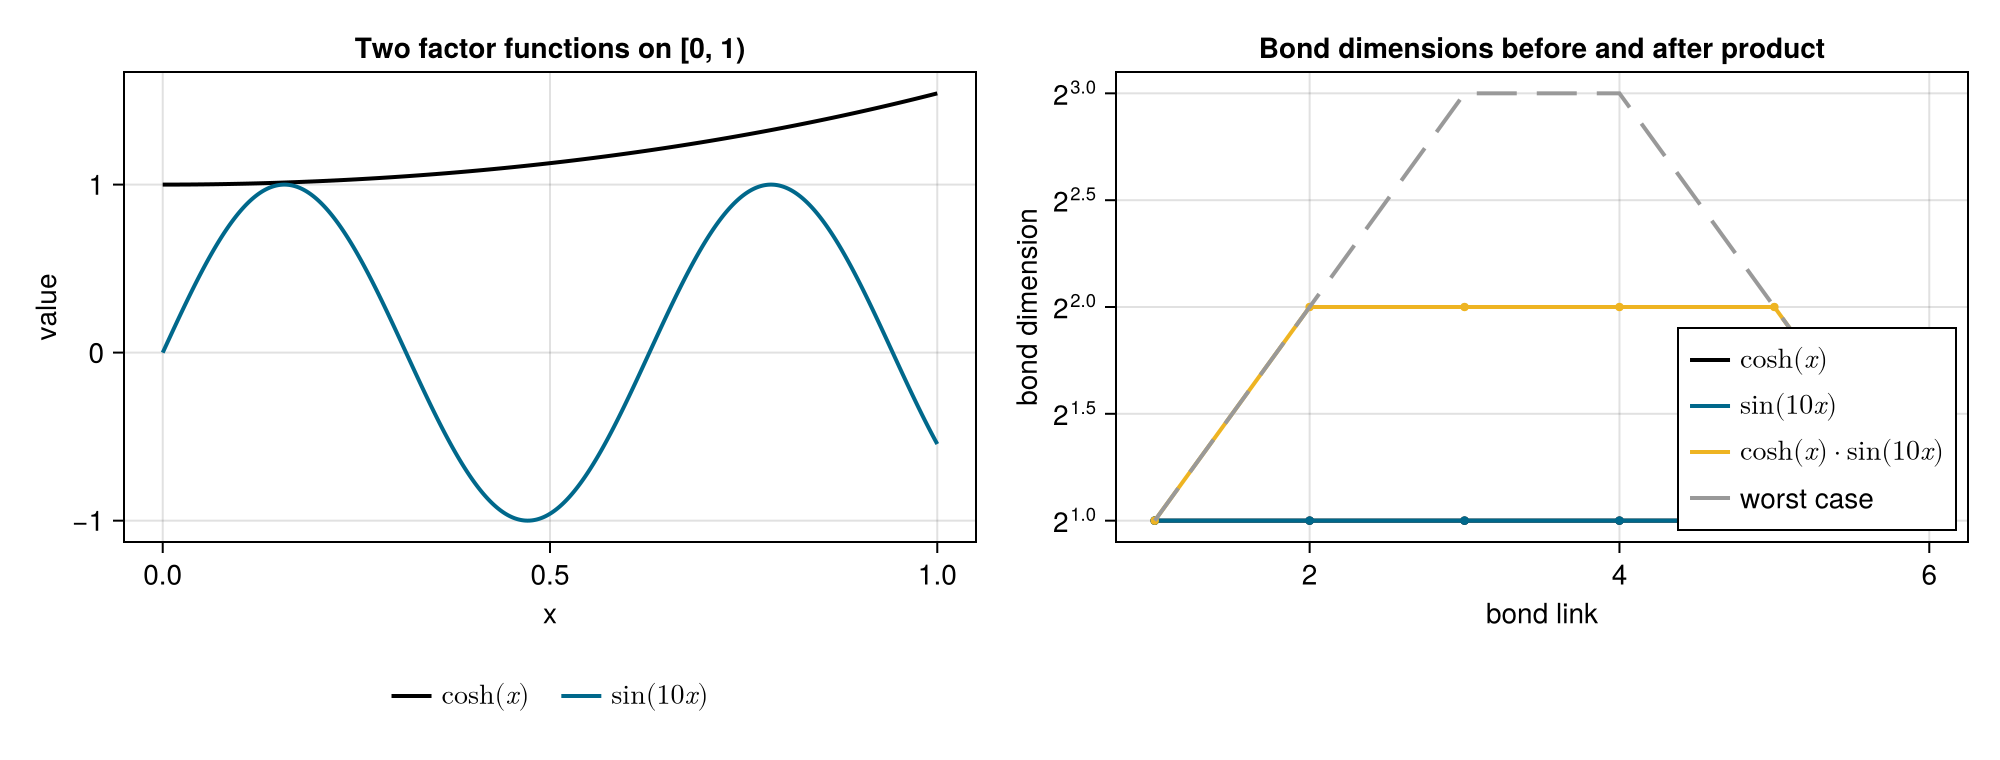

In [7]:
worst_case_bond_dims(num_bonds; base=2) =
    [base^min(k, num_bonds + 1 - k) for k in 1:num_bonds]

fig = Figure(size=(1000, 380))

ax1 = Axis(
    fig[1, 1],
    xlabel="x", ylabel="value",
    title="Two factor functions on [0, 1)",
)
xs = range(0, 1, length=1000)
lines!(ax1, xs, f.(xs); color=:black, linewidth=2, label=L"\cosh(x)")
lines!(ax1, xs, g.(xs); color=:deepskyblue4, linewidth=2, label=L"\sin(10x)")
Legend(fig[2, 1], ax1, orientation=:horizontal, framevisible=false)

ax2 = Axis(
    fig[1, 2],
    xlabel="bond link", ylabel="bond dimension",
    title="Bond dimensions before and after product",
    yscale=log2,
)
idx_f = 1:length(bond_f)
lines!(ax2, idx_f, bond_f; color=:black, linewidth=2, label=L"\cosh(x)")
scatter!(ax2, idx_f, bond_f; color=:black, markersize=6)

idx_g = 1:length(bond_g)
lines!(ax2, idx_g, bond_g; color=:deepskyblue4, linewidth=2, linestyle=Linestyle([0, 8, 8]), label=L"\sin(10x)")
scatter!(ax2, idx_g, bond_g; color=:deepskyblue4, markersize=6)

idx_h = 1:length(bond_h)
lines!(ax2, idx_h, bond_h; color=:goldenrod2, linewidth=2, label=L"\cosh(x)\cdot\sin(10x)")
scatter!(ax2, idx_h, bond_h; color=:goldenrod2, markersize=6)

worst = worst_case_bond_dims(max(length(bond_f), length(bond_g), length(bond_h)))
lines!(ax2, 1:length(worst), worst; color=:gray60, linewidth=2, linestyle=Linestyle([0, 10, 15]), label="worst case")
axislegend(ax2; position=:rb)

fig

The left panel shows the two factor functions. The right panel compares the bond-dimension profiles.

`cosh(x)` stays at bond dimension 2 throughout, as we saw in Notebook 01. `sin(10x)` needs a moderate rank. The product of the two functions has larger bond dimensions than either factor alone: this is rank growth under multiplication.

## Part 2: Integration of a QTT

A QTT built on a `DiscretizedGrid` with physical bounds can compute its own definite integral. The method sums the tensor train and multiplies by the grid spacing. The result is a grid-based approximation to the analytic integral.

We use $x^2$ on $[-1, 2]$ as the example function. The exact integral is

$$\int_{-1}^{2} x^2 \, dx = \left[\frac{x^3}{3}\right]_{-1}^{2} = \frac{8}{3} - \frac{-1}{3} = 3.$$

In [8]:
integral_function(x) = x^2
exact_integral = 3.0

R_int = 7
grid_int = QG.DiscretizedGrid{1}(R_int, -1.0, 2.0; includeendpoint=true)

qtt_int, _, _ = QTCI.quanticscrossinterpolate(
    Float64, integral_function, grid_int;
    tolerance=1e-12, maxbonddim=32, maxiter=200,
)

computed_integral = QTCI.integral(qtt_int)
integral_error = abs(computed_integral - exact_integral)

println("Integral of x^2 from -1 to 2:")
println("  Exact value:        $exact_integral")
println("  QTT approximation:  $computed_integral")
println("  Absolute error:     $integral_error")

Integral of x^2 from -1 to 2:
  Exact value:        3.0
  QTT approximation:  3.059334118668238
  Absolute error:     0.05933411866823812


### Convergence with R

The integral accuracy depends on the grid resolution. More bits mean a finer grid on the same interval, so the grid-based approximation converges toward the exact analytic value.

In the next cell we sweep over `R` and record the computed integral, the absolute error, and the maximum QTT bond dimension for each resolution.

In [9]:
sweep_R_values = 3:10
sweep_integrals = Float64[]
sweep_errors = Float64[]
sweep_max_bond_dims = Int[]

for sweep_R in sweep_R_values
    sweep_grid = QG.DiscretizedGrid{1}(sweep_R, -1.0, 2.0; includeendpoint=true)
    sweep_qtt, _, _ = QTCI.quanticscrossinterpolate(
        Float64, integral_function, sweep_grid;
        tolerance=1e-12, maxbonddim=32, maxiter=200,
    )
    sweep_integral = QTCI.integral(sweep_qtt)
    sweep_error = abs(sweep_integral - exact_integral)

    sweep_simple = STT.TensorTrain(sweep_qtt.tci)
    sweep_sites = [Tensor4all.Index(2; tags=["x", "bit=$i"]) for i in 1:length(sweep_simple)]
    sweep_indexed = TN.TensorTrain(sweep_simple, sweep_sites)
    sweep_bond_dims = TN.linkdims(sweep_indexed)

    push!(sweep_integrals, sweep_integral)
    push!(sweep_errors, sweep_error)
    push!(sweep_max_bond_dims, maximum(sweep_bond_dims))

    println("R = $sweep_R  integral = $sweep_integral  max bond dim = $(maximum(sweep_bond_dims))")
end

R = 3  integral = 4.163265306122447  max bond dim = 2
R = 4  integral = 3.5200000000000005  max bond dim = 3
R = 5  integral = 3.246618106139438  max bond dim = 3
R = 6  integral = 3.1201814058956905  max bond dim = 3
R = 7  integral = 3.059334118668238  max bond dim = 3
R = 8  integral = 3.029480968858132  max bond dim = 3
R = 9  integral = 3.014694337108084  max bond dim = 3
R = 10  integral = 3.0073356782277414  max bond dim = 3


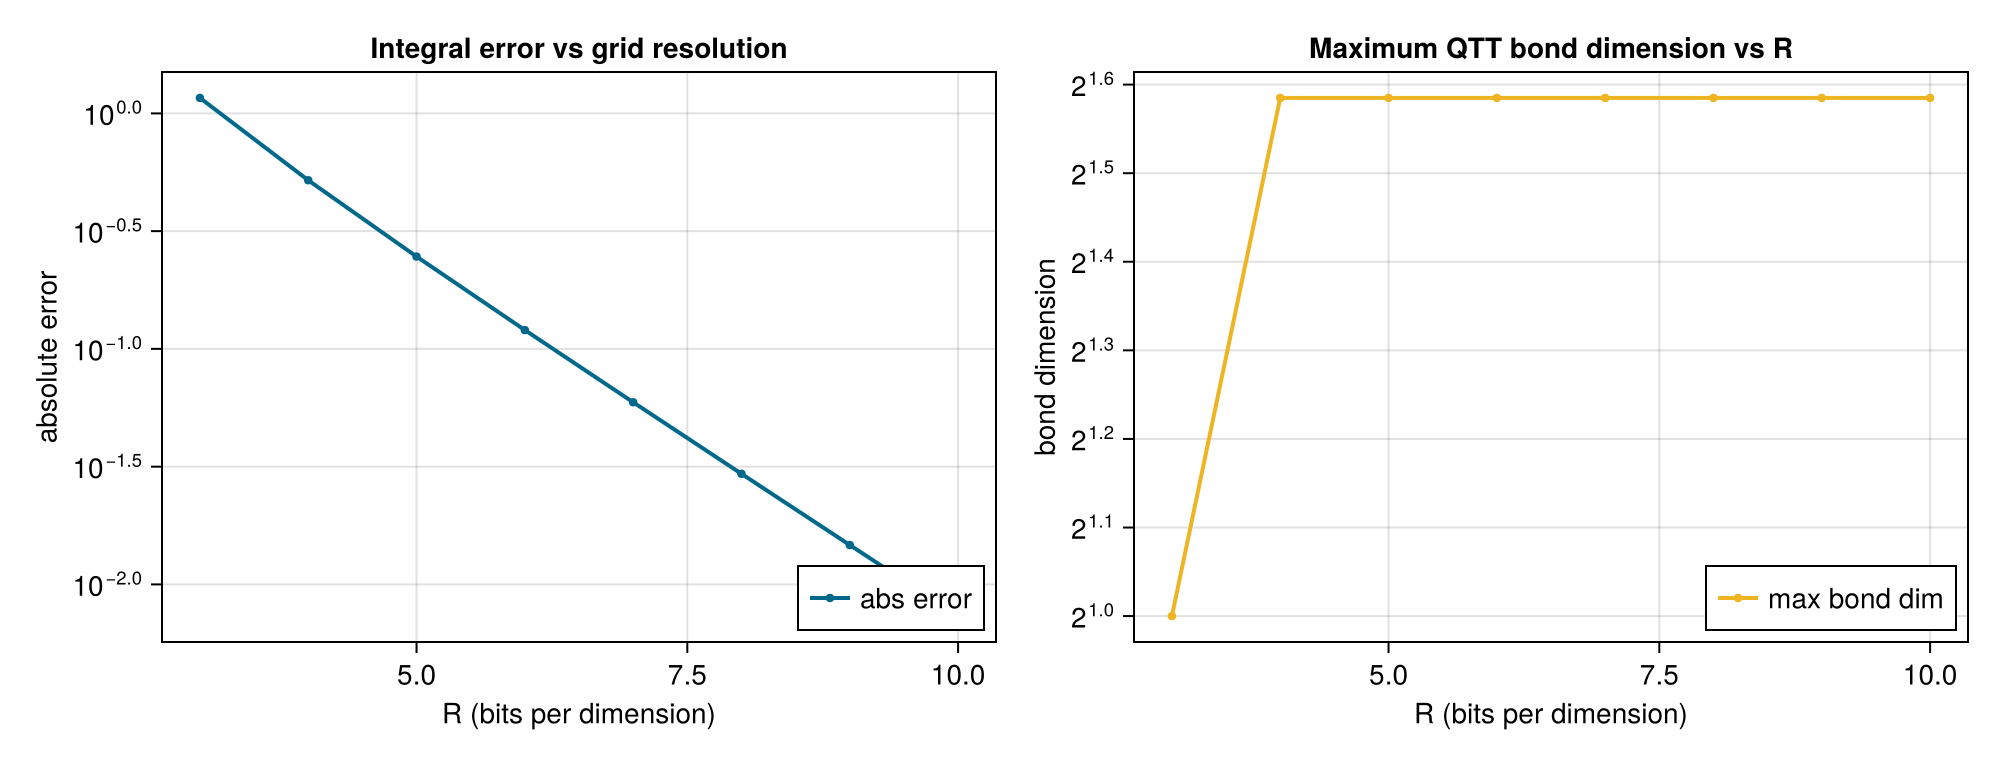

In [10]:
fig2 = Figure(size=(1000, 380))

ax2_1 = Axis(
    fig2[1, 1],
    xlabel="R (bits per dimension)", ylabel="absolute error",
    title="Integral error vs grid resolution",
    yscale=log10,
)
scatterlines!(ax2_1, collect(sweep_R_values), sweep_errors;
    color=:deepskyblue4, linewidth=2, markersize=6, label="abs error")
axislegend(ax2_1; position=:rb)

ax2_2 = Axis(
    fig2[1, 2],
    xlabel="R (bits per dimension)", ylabel="bond dimension",
    title="Maximum QTT bond dimension vs R",
    yscale=log2,
)
scatterlines!(ax2_2, collect(sweep_R_values), sweep_max_bond_dims;
    color=:goldenrod2, linewidth=2, markersize=6, label="max bond dim")
axislegend(ax2_2; position=:rb)

fig2

The left panel shows how the integral error decreases as the grid becomes finer. The right panel shows that the maximum bond dimension stays at 2 for all values of `R`: `x^2` is a simple polynomial whose QTT representation stays extremely compact regardless of grid resolution.

The integral error does not decrease monotonically because the grid points for different values of `R` sample the function at different locations on the same interval. As `R` increases, the sampled integral approaches the exact value from either side.

## What to notice

- The elementwise product of two QTTs has larger bond dimensions than either factor alone. This is rank growth under multiplication.
- `cosh(x)` stays at bond dimension 2, but multiplying with an oscillatory function increases the internal rank.
- `QuanticsTCI.integral` computes the definite integral of a QTT on a physical interval.
- The integral converges toward the exact analytic value as the grid resolution `R` increases.
- `x^2` is simple enough that its QTT bond dimension stays at 2 regardless of `R`.

## API recap

- `Tensor4all.QuanticsTCI.quanticscrossinterpolate` (building factor and product QTTs)
- `Tensor4all.QuanticsTCI.integral` (definite integral on a `DiscretizedGrid`)
- `Tensor4all.SimpleTT.TensorTrain`
- `Tensor4all.TensorNetworks.TensorTrain`
- `Tensor4all.TensorNetworks.linkdims`